# Task 4 — Деревья решений и случайные леса

**Задание:**
- **Part 1:** Мультиклассовая классификация — Decision Tree и Random Forest, кросс-валидация, confusion matrix, classification report, AUC-ROC, оптимальный порог, Precision vs Recall, feature importance.
- **Part 2:** Регрессия — Decision Tree и Random Forest, кросс-валидация, MAE, MSE, RMSE, residuals, feature importance.

---
# Part 1 — Классификация (Wine dataset)
---

## 1. Импорты и настройки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine, fetch_california_housing
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100

## 2. Загрузка и обзор данных

In [2]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print(f'Классы: {dict(enumerate(wine.target_names))}')
print(f'Размер: {df.shape}')
df.head()

Классы: {0: np.str_('class_0'), 1: np.str_('class_1'), 2: np.str_('class_2')}
Размер: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [4]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


## 3. EDA (Exploratory Data Analysis)

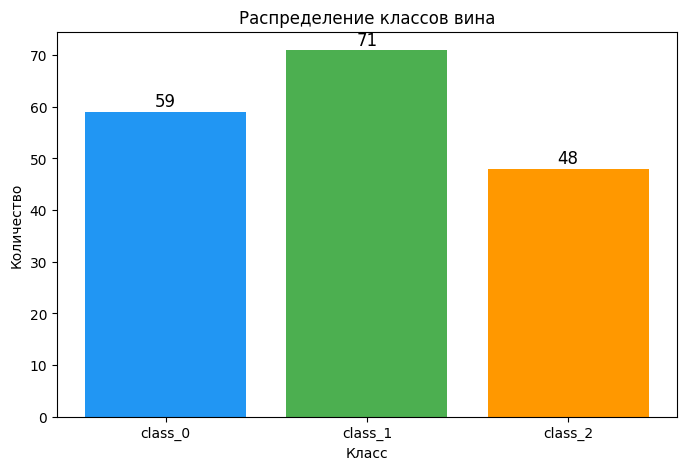

Распределение классов:
target
0    59
1    71
2    48
Name: count, dtype: int64


In [5]:
# Распределение классов
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['target'].value_counts().sort_index()
bars = ax.bar(wine.target_names, counts.values, color=['#2196F3', '#4CAF50', '#FF9800'])
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(count), ha='center', fontsize=12)
ax.set_title('Распределение классов вина')
ax.set_xlabel('Класс')
ax.set_ylabel('Количество')
plt.show()

print(f'Распределение классов:\n{counts}')

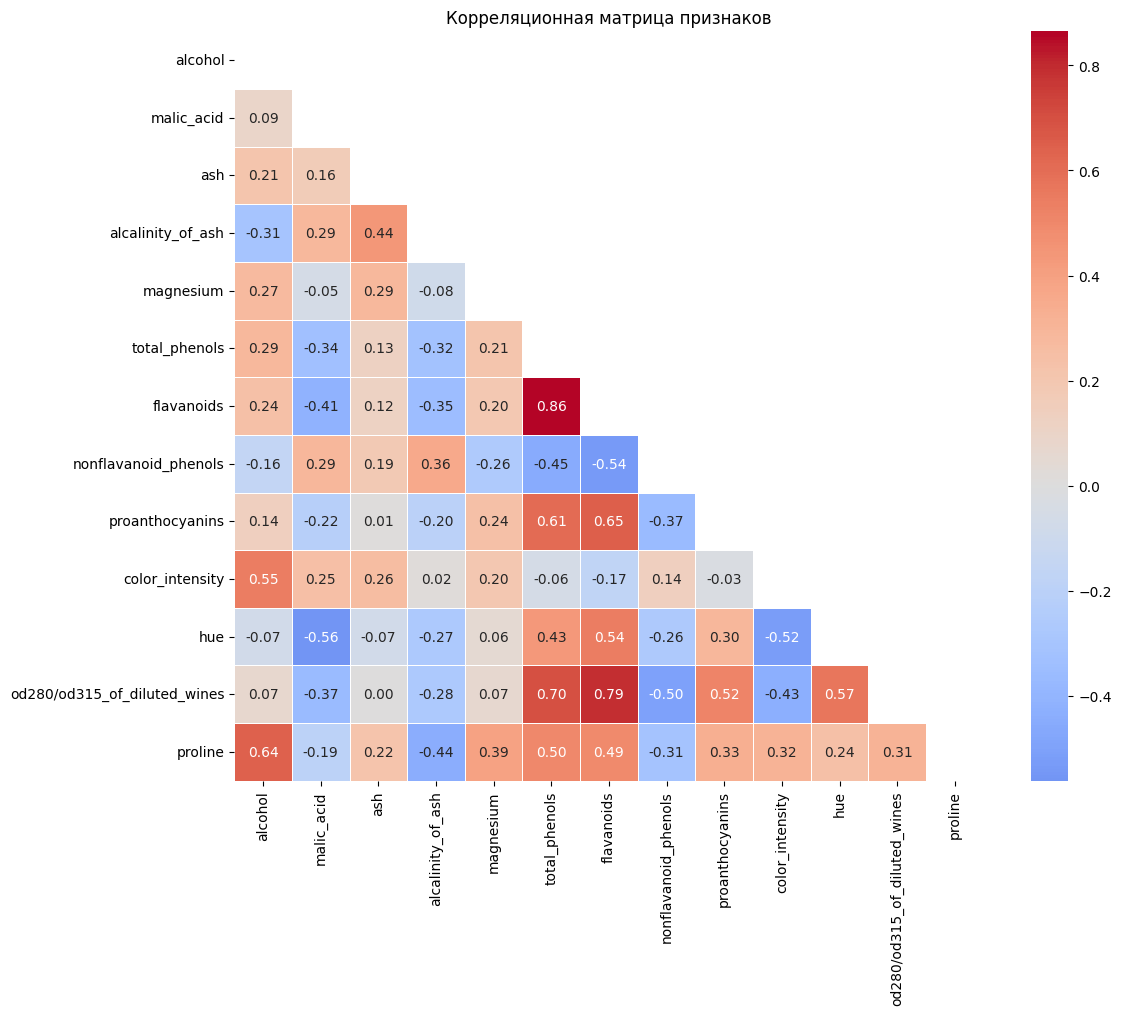

In [6]:
# Корреляционная матрица
fig, ax = plt.subplots(figsize=(12, 10))
corr = df.drop('target', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

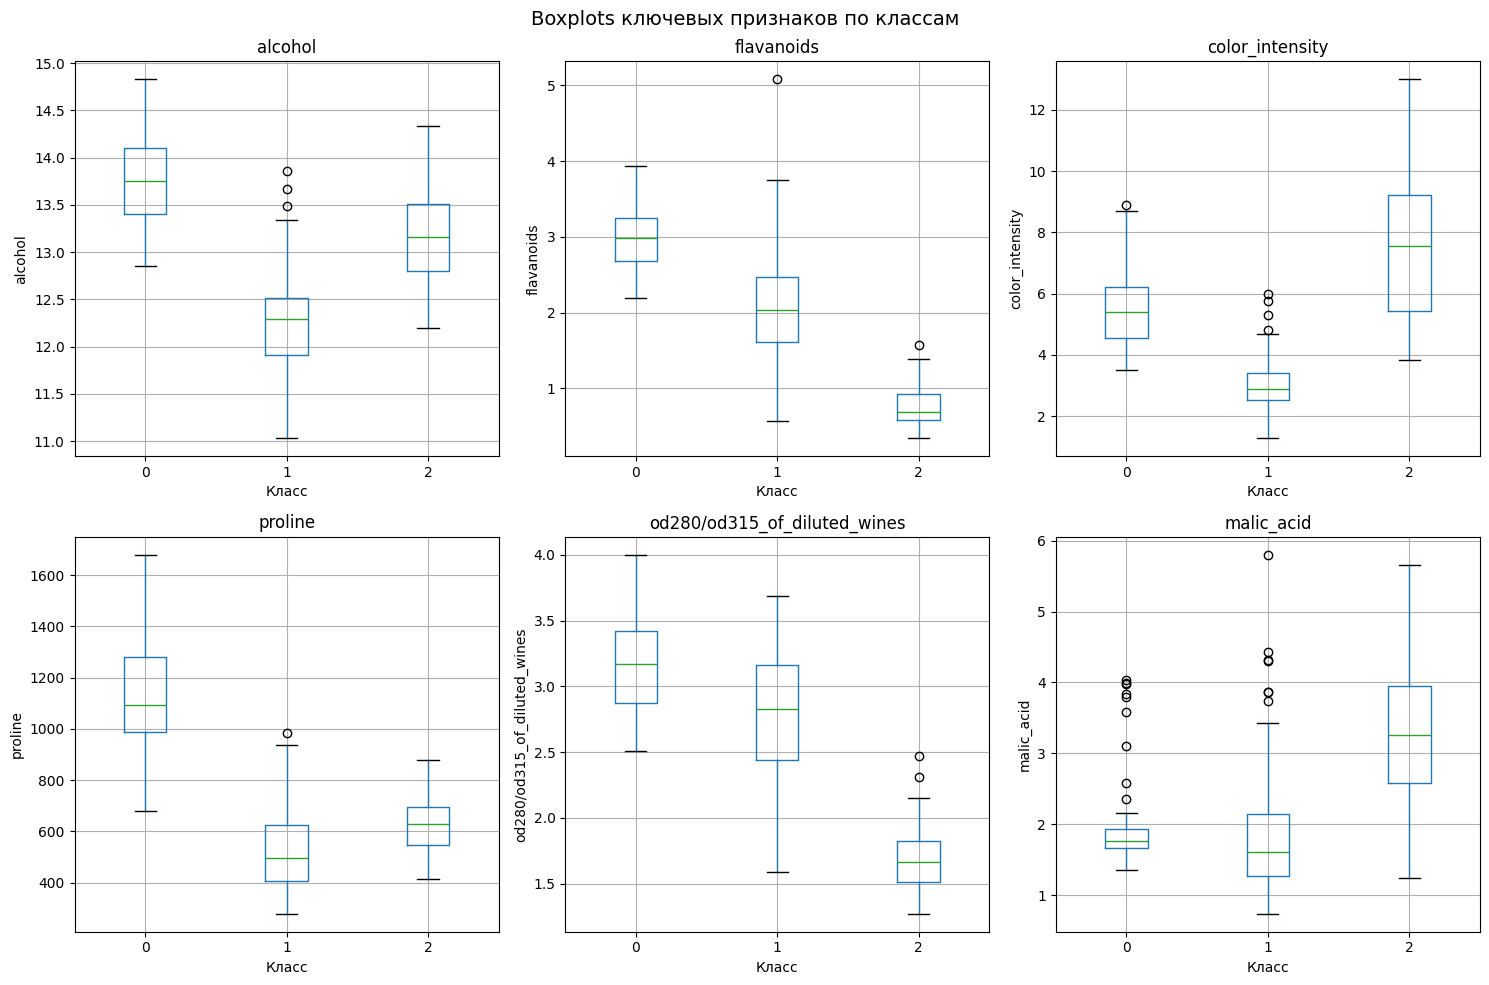

In [7]:
# Boxplots ключевых признаков по классам
key_features = ['alcohol', 'flavanoids', 'color_intensity', 'proline', 'od280/od315_of_diluted_wines', 'malic_acid']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, feature in enumerate(key_features):
    ax = axes[i // 3, i % 3]
    df.boxplot(column=feature, by='target', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('Класс')
    ax.set_ylabel(feature)
plt.suptitle('Boxplots ключевых признаков по классам', fontsize=14)
plt.tight_layout()
plt.show()

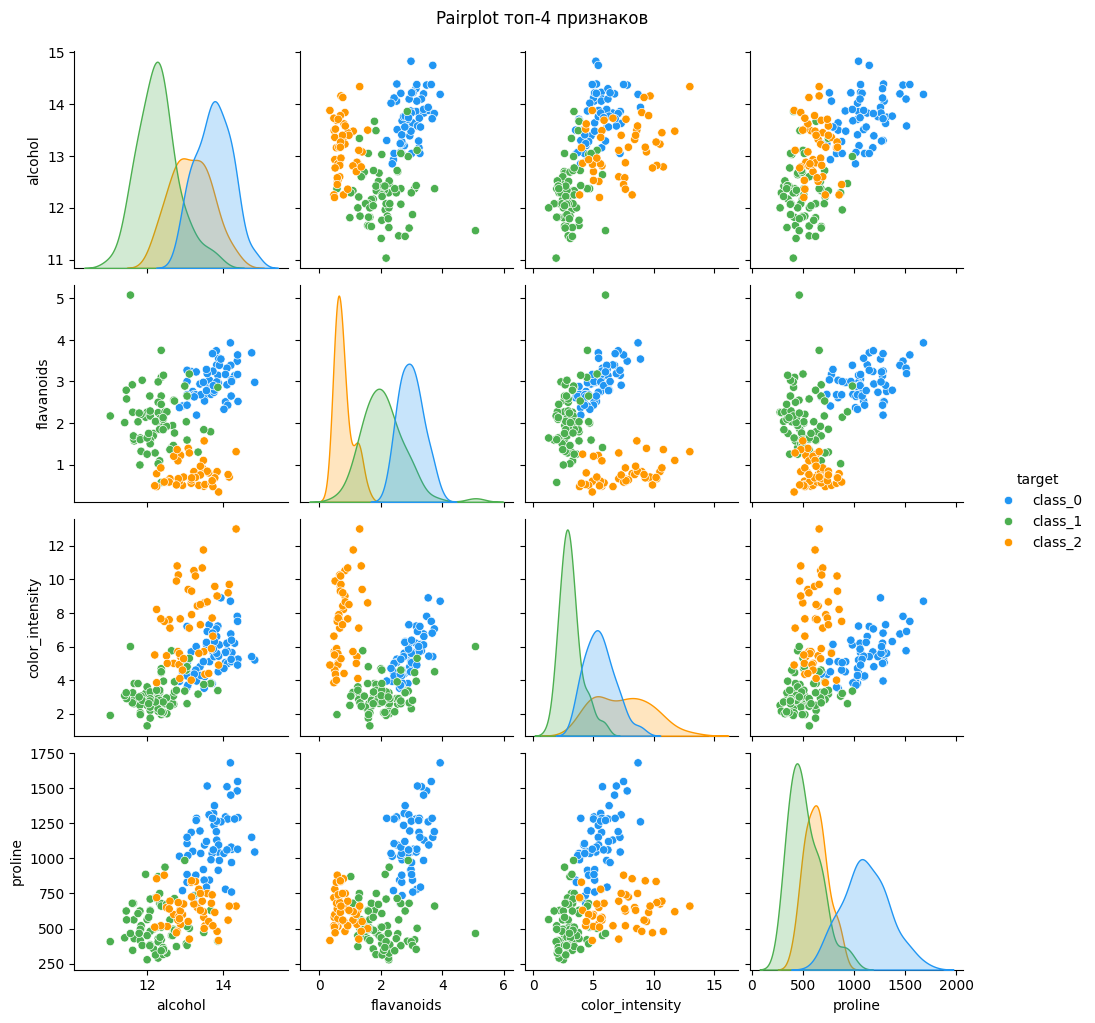

In [8]:
# Pairplot топ-4 признаков
top_features = ['alcohol', 'flavanoids', 'color_intensity', 'proline']
df_plot = df[top_features + ['target']].copy()
df_plot['target'] = df_plot['target'].map(dict(enumerate(wine.target_names)))

sns.pairplot(df_plot, hue='target', palette=['#2196F3', '#4CAF50', '#FF9800'])
plt.suptitle('Pairplot топ-4 признаков', y=1.02)
plt.show()

## 4. Предобработка данных

In [9]:
# Проверка пропусков
print(f'Пропуски по столбцам:\n{df.isnull().sum().sum()} (всего)')

# Разделение на признаки и target
X = df.drop('target', axis=1)
y = df['target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} записей')
print(f'Test:  {X_test.shape[0]} записей')

# StandardScaler (для сравнимости, деревья не требуют масштабирования)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Пропуски по столбцам:
0 (всего)

Train: 142 записей
Test:  36 записей


## 5. Decision Tree — классификация

In [10]:
# Базовая модель без ограничений
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

y_pred_base = dt_base.predict(X_test)
print(f'Базовое дерево (без ограничений):')
print(f'  Глубина: {dt_base.get_depth()}')
print(f'  Листьев: {dt_base.get_n_leaves()}')
print(f'  Train accuracy: {dt_base.score(X_train, y_train):.4f}')
print(f'  Test accuracy:  {accuracy_score(y_test, y_pred_base):.4f}')

Базовое дерево (без ограничений):
  Глубина: 4
  Листьев: 8
  Train accuracy: 1.0000
  Test accuracy:  0.9444


Лучшая глубина: 4 (CV accuracy = 0.9022)


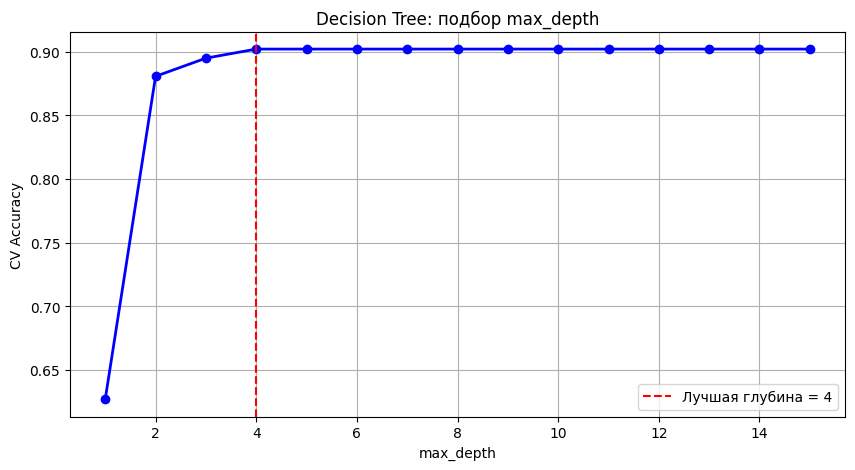

In [11]:
# Подбор max_depth через кросс-валидацию
depths = range(1, 16)
cv_scores_dt = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=skf, scoring='accuracy')
    cv_scores_dt.append(scores.mean())

best_depth_dt = depths[np.argmax(cv_scores_dt)]
print(f'Лучшая глубина: {best_depth_dt} (CV accuracy = {max(cv_scores_dt):.4f})')

# График
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, cv_scores_dt, 'bo-', linewidth=2, markersize=6)
ax.axvline(x=best_depth_dt, color='red', linestyle='--', label=f'Лучшая глубина = {best_depth_dt}')
ax.set_xlabel('max_depth')
ax.set_ylabel('CV Accuracy')
ax.set_title('Decision Tree: подбор max_depth')
ax.legend()
ax.grid(True)
plt.show()

In [12]:
# Подбор min_samples_split и min_samples_leaf
min_splits = [2, 5, 10, 15, 20]
min_leafs = [1, 2, 5, 10]

best_score_pruning = 0
best_params_pruning = {}

for ms in min_splits:
    for ml in min_leafs:
        dt = DecisionTreeClassifier(
            max_depth=best_depth_dt, min_samples_split=ms,
            min_samples_leaf=ml, random_state=42
        )
        scores = cross_val_score(dt, X_train, y_train, cv=skf, scoring='accuracy')
        if scores.mean() > best_score_pruning:
            best_score_pruning = scores.mean()
            best_params_pruning = {'min_samples_split': ms, 'min_samples_leaf': ml}

print(f'Лучшие параметры pruning: {best_params_pruning}')
print(f'CV Accuracy: {best_score_pruning:.4f}')

Лучшие параметры pruning: {'min_samples_split': 2, 'min_samples_leaf': 1}
CV Accuracy: 0.9022


In [13]:
# Финальная модель Decision Tree
dt_final = DecisionTreeClassifier(
    max_depth=best_depth_dt,
    min_samples_split=best_params_pruning['min_samples_split'],
    min_samples_leaf=best_params_pruning['min_samples_leaf'],
    random_state=42
)
dt_final.fit(X_train, y_train)
y_pred_dt = dt_final.predict(X_test)
y_prob_dt = dt_final.predict_proba(X_test)

print(f'Decision Tree (оптимизированное):')
print(f'  Глубина: {dt_final.get_depth()}')
print(f'  Листьев: {dt_final.get_n_leaves()}')
print(f'  Test accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')

Decision Tree (оптимизированное):
  Глубина: 4
  Листьев: 8
  Test accuracy: 0.9444


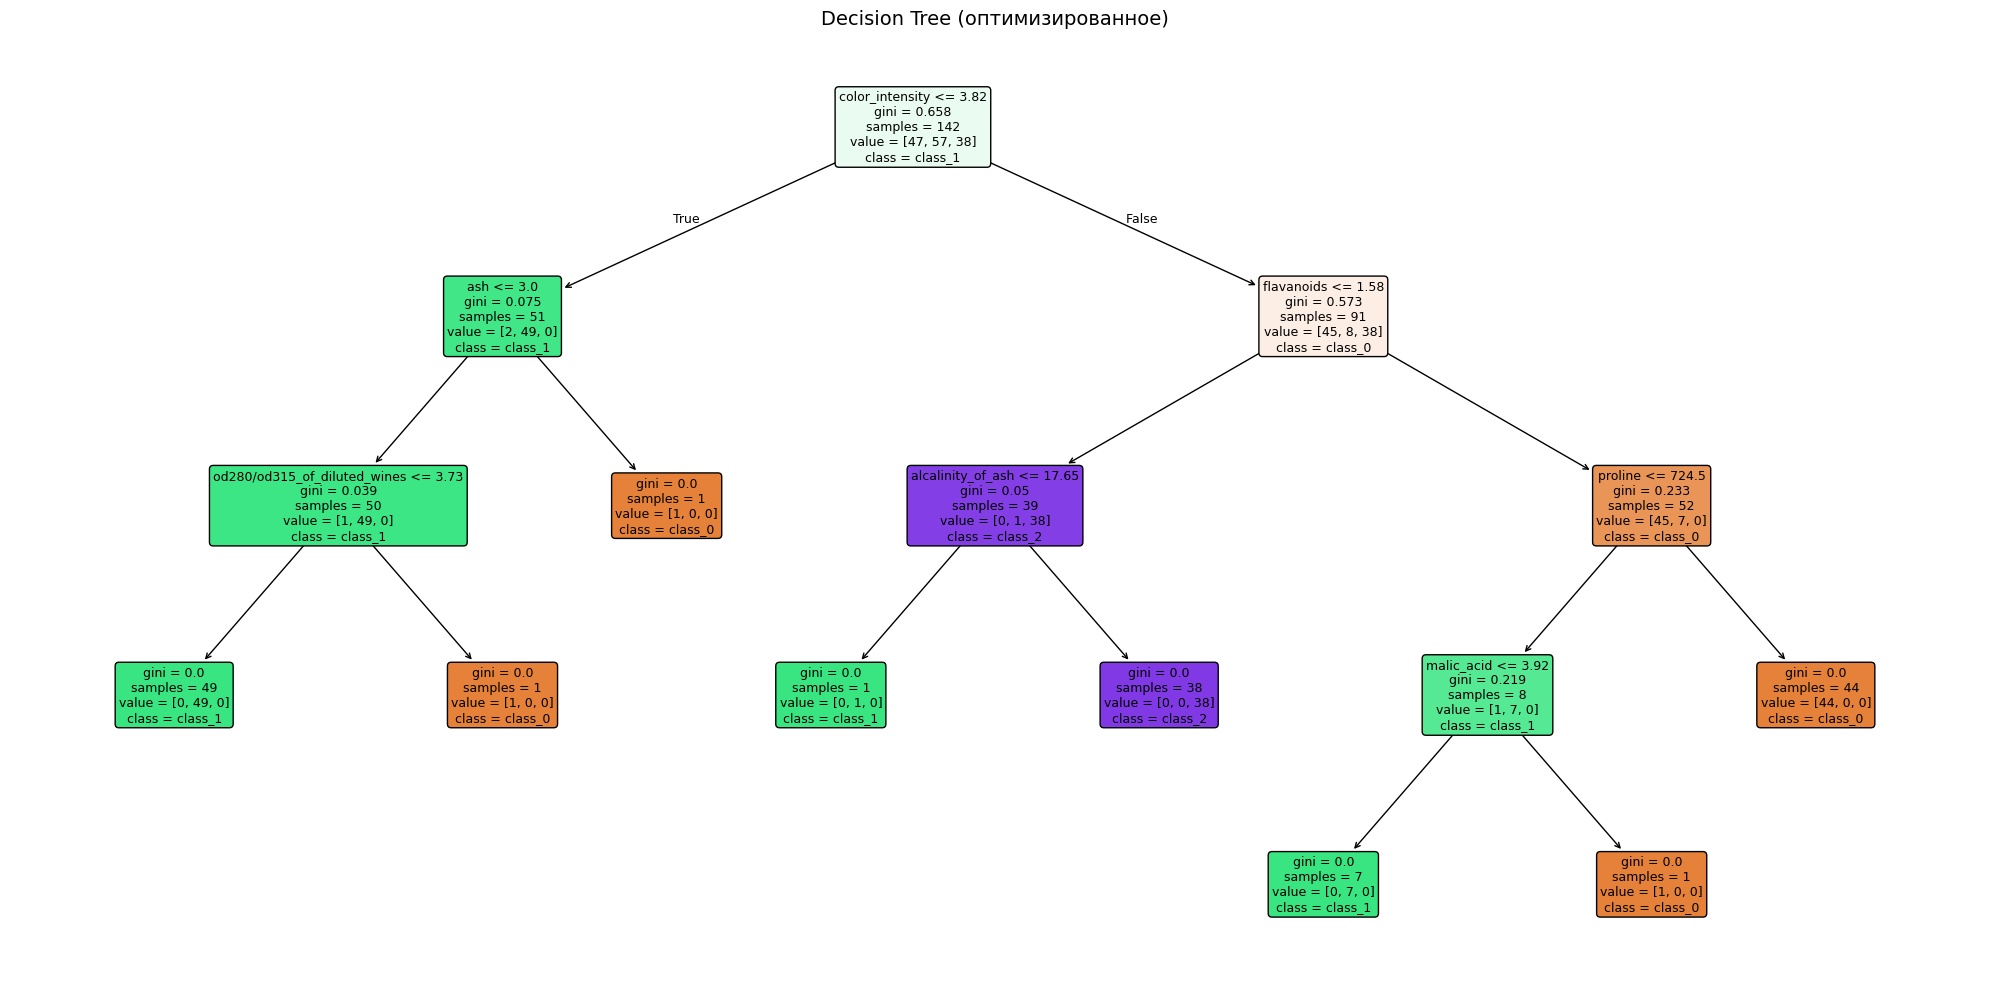

In [14]:
# Визуализация дерева
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_final, feature_names=wine.feature_names, class_names=list(wine.target_names),
          filled=True, rounded=True, ax=ax, fontsize=9)
ax.set_title('Decision Tree (оптимизированное)', fontsize=14)
plt.tight_layout()
plt.show()

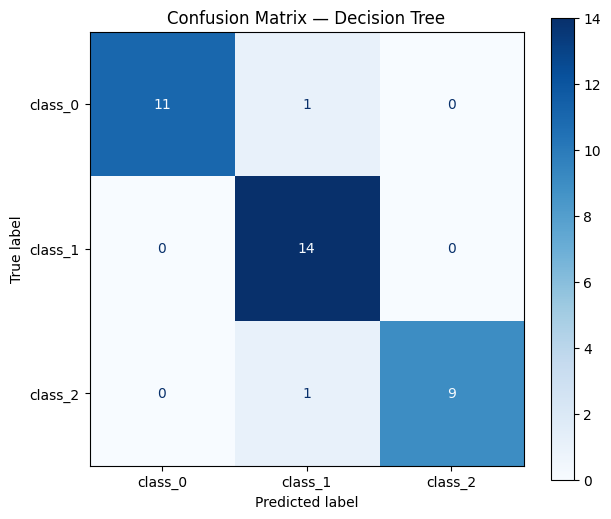

Classification Report — Decision Tree:
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [15]:
# Confusion Matrix — Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=wine.target_names)
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — Decision Tree')
plt.show()

print('Classification Report — Decision Tree:')
print(classification_report(y_test, y_pred_dt, target_names=list(wine.target_names)))

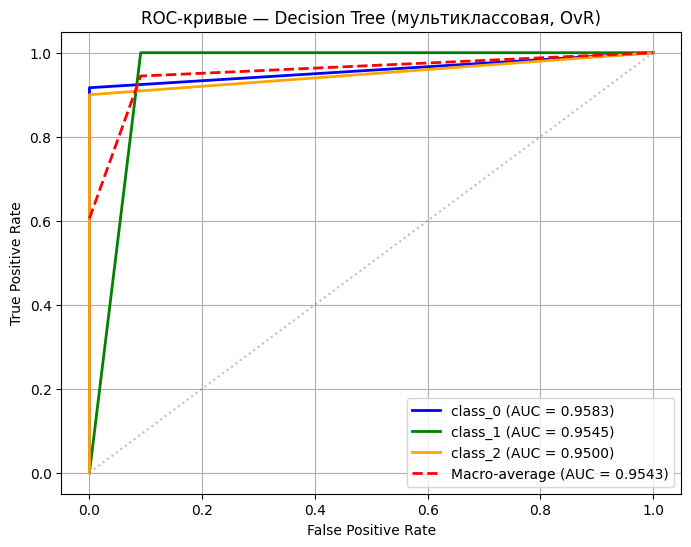

In [16]:
# ROC-кривая (OvR) — Decision Tree
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3
colors = ['blue', 'green', 'orange']

fig, ax = plt.subplots(figsize=(8, 6))

for i, (color, name) in enumerate(zip(colors, wine.target_names)):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_prob_dt[:, i])
    auc_i = auc(fpr_i, tpr_i)
    ax.plot(fpr_i, tpr_i, color=color, lw=2, label=f'{name} (AUC = {auc_i:.4f})')

# Macro-average
all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_prob_dt[:, i])[0] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_prob_dt[:, i])
    mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
mean_tpr /= n_classes
macro_auc_dt = auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, color='red', lw=2, linestyle='--', label=f'Macro-average (AUC = {macro_auc_dt:.4f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые — Decision Tree (мультиклассовая, OvR)')
ax.legend(loc='lower right')
ax.grid(True)
plt.show()

## 6. Random Forest — классификация

n_estimators=50: CV accuracy = 0.9722 (+/- 0.0403)


n_estimators=100: CV accuracy = 0.9791 (+/- 0.0277)


n_estimators=200: CV accuracy = 0.9791 (+/- 0.0277)


n_estimators=300: CV accuracy = 0.9791 (+/- 0.0277)


n_estimators=500: CV accuracy = 0.9791 (+/- 0.0277)

Лучшее n_estimators: 100


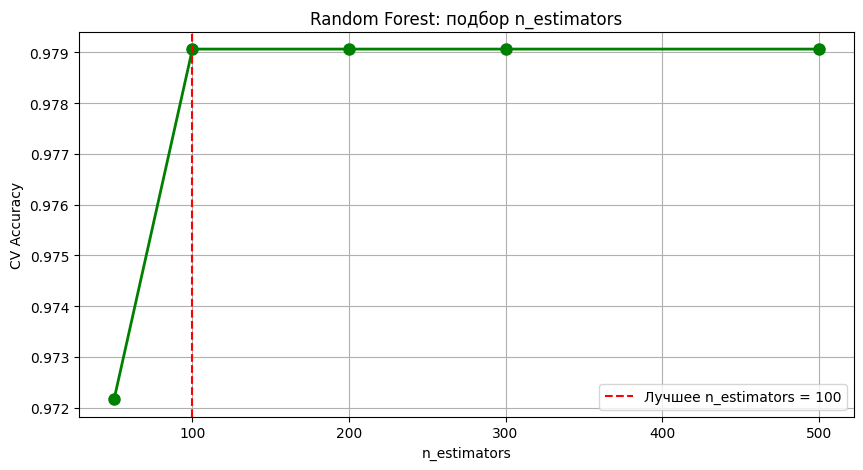

In [17]:
# Подбор n_estimators через кросс-валидацию
n_estimators_list = [50, 100, 200, 300, 500]
cv_scores_n_est = []

for n_est in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n_est, random_state=42)
    scores = cross_val_score(rf, X_train, y_train, cv=skf, scoring='accuracy')
    cv_scores_n_est.append(scores.mean())
    print(f'n_estimators={n_est}: CV accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})')

best_n_est = n_estimators_list[np.argmax(cv_scores_n_est)]
print(f'\nЛучшее n_estimators: {best_n_est}')

# График
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_estimators_list, cv_scores_n_est, 'go-', linewidth=2, markersize=8)
ax.axvline(x=best_n_est, color='red', linestyle='--', label=f'Лучшее n_estimators = {best_n_est}')
ax.set_xlabel('n_estimators')
ax.set_ylabel('CV Accuracy')
ax.set_title('Random Forest: подбор n_estimators')
ax.legend()
ax.grid(True)
plt.show()

max_depth=1: CV accuracy = 0.9650


max_depth=2: CV accuracy = 0.9791


max_depth=3: CV accuracy = 0.9722


max_depth=4: CV accuracy = 0.9791


max_depth=5: CV accuracy = 0.9791


...

max_depth=12: CV accuracy = 0.9791


max_depth=13: CV accuracy = 0.9791


max_depth=14: CV accuracy = 0.9791


max_depth=15: CV accuracy = 0.9791


max_depth=None: CV accuracy = 0.9791

Лучшая глубина RF: 2


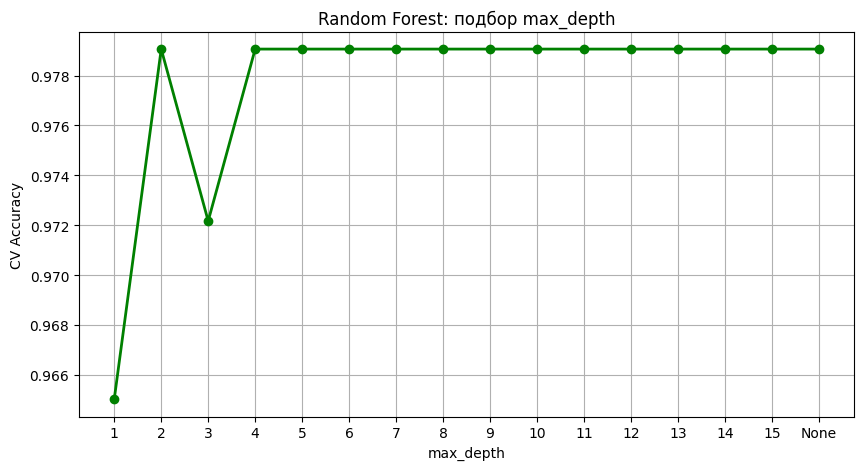

In [18]:
# Подбор max_depth через кросс-валидацию
depths_rf = list(range(1, 16)) + [None]
cv_scores_depth_rf = []

for depth in depths_rf:
    rf = RandomForestClassifier(n_estimators=best_n_est, max_depth=depth, random_state=42)
    scores = cross_val_score(rf, X_train, y_train, cv=skf, scoring='accuracy')
    cv_scores_depth_rf.append(scores.mean())
    label = depth if depth is not None else 'None'
    print(f'max_depth={label}: CV accuracy = {scores.mean():.4f}')

best_depth_rf_idx = np.argmax(cv_scores_depth_rf)
best_depth_rf = depths_rf[best_depth_rf_idx]
print(f'\nЛучшая глубина RF: {best_depth_rf}')

# График (без None для наглядности)
fig, ax = plt.subplots(figsize=(10, 5))
plot_depths = list(range(1, 16)) + [16]  # 16 обозначает None
ax.plot(plot_depths, cv_scores_depth_rf, 'go-', linewidth=2, markersize=6)
ax.set_xticks(plot_depths)
ax.set_xticklabels([str(d) for d in range(1, 16)] + ['None'])
ax.set_xlabel('max_depth')
ax.set_ylabel('CV Accuracy')
ax.set_title('Random Forest: подбор max_depth')
ax.grid(True)
plt.show()

In [19]:
# Финальная модель Random Forest
rf_final = RandomForestClassifier(
    n_estimators=best_n_est, max_depth=best_depth_rf, random_state=42
)
rf_final.fit(X_train, y_train)
y_pred_rf = rf_final.predict(X_test)
y_prob_rf = rf_final.predict_proba(X_test)

print(f'Random Forest (оптимизированный):')
print(f'  n_estimators: {best_n_est}')
print(f'  max_depth: {best_depth_rf}')
print(f'  Test accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')

Random Forest (оптимизированный):
  n_estimators: 100
  max_depth: 2
  Test accuracy: 0.9722


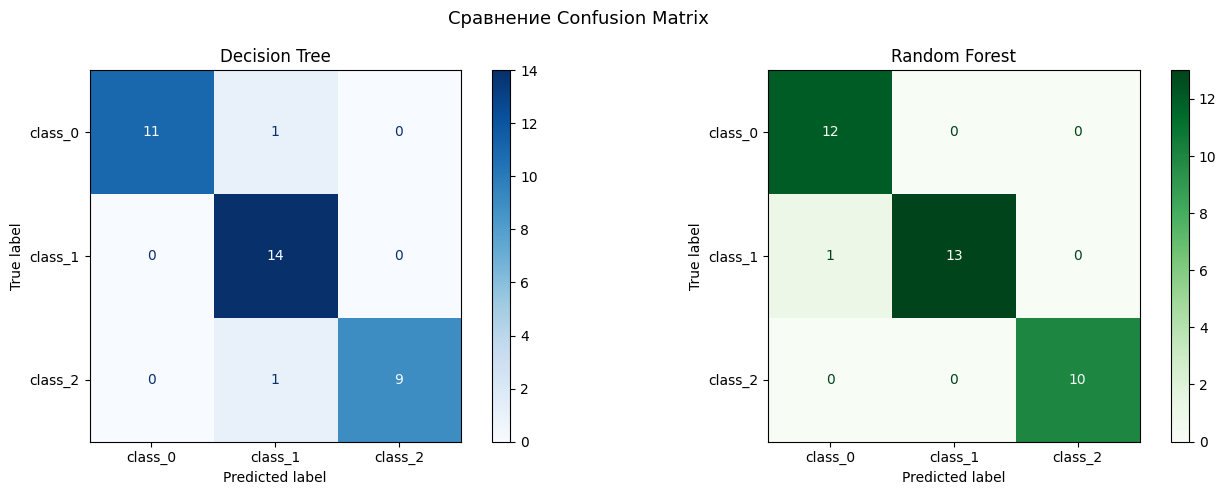

Classification Report — Random Forest:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



In [20]:
# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=wine.target_names).plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Decision Tree')

ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=wine.target_names).plot(cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest')

plt.suptitle('Сравнение Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print('Classification Report — Random Forest:')
print(classification_report(y_test, y_pred_rf, target_names=list(wine.target_names)))

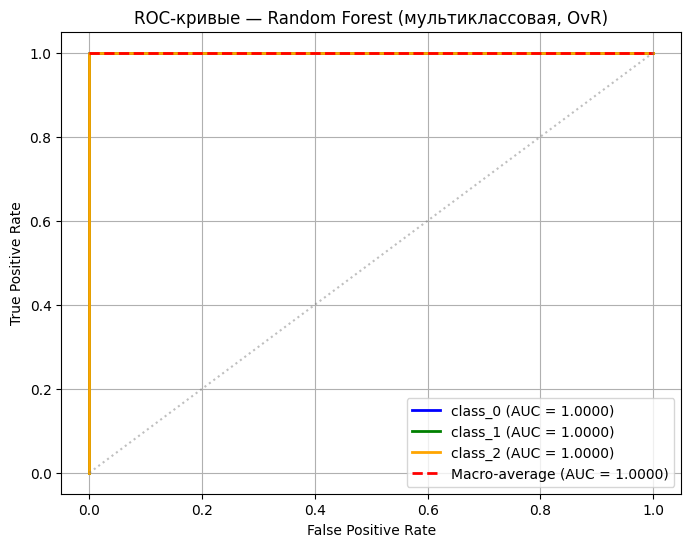

In [21]:
# ROC-кривая (OvR) — Random Forest
fig, ax = plt.subplots(figsize=(8, 6))

for i, (color, name) in enumerate(zip(colors, wine.target_names)):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    auc_i = auc(fpr_i, tpr_i)
    ax.plot(fpr_i, tpr_i, color=color, lw=2, label=f'{name} (AUC = {auc_i:.4f})')

# Macro-average
all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_prob_rf[:, i])[0] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
mean_tpr /= n_classes
macro_auc_rf = auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, color='red', lw=2, linestyle='--', label=f'Macro-average (AUC = {macro_auc_rf:.4f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые — Random Forest (мультиклассовая, OvR)')
ax.legend(loc='lower right')
ax.grid(True)
plt.show()

## 7. Оптимальный порог

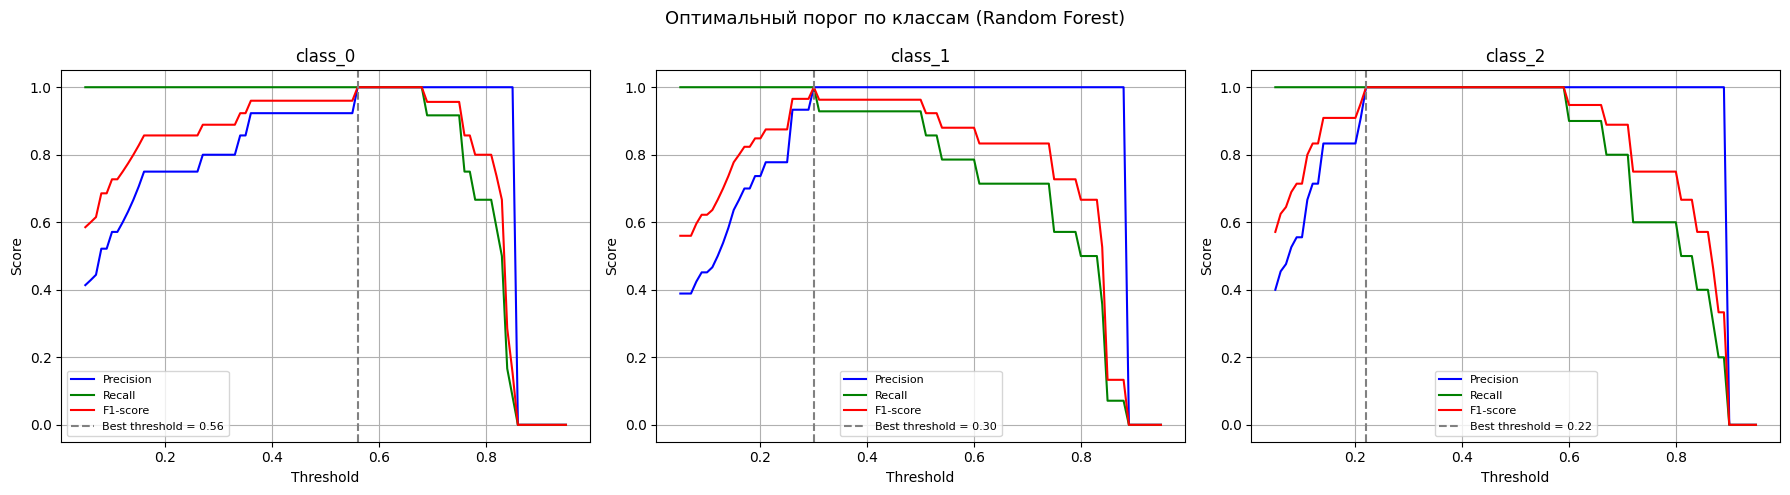

Оптимальные пороги:
  class_0: 0.56
  class_1: 0.30
  class_2: 0.22


In [22]:
# Определение оптимального порога для каждого класса (Random Forest)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

best_thresholds = {}

for i, name in enumerate(wine.target_names):
    y_true_binary = (y_test == i).astype(int)
    y_scores = y_prob_rf[:, i]
    
    thresholds = np.arange(0.05, 0.96, 0.01)
    precisions, recalls, f1s = [], [], []
    
    for t in thresholds:
        y_pred_t = (y_scores >= t).astype(int)
        if y_pred_t.sum() == 0 or y_true_binary.sum() == 0:
            precisions.append(0)
            recalls.append(0)
            f1s.append(0)
            continue
        precisions.append(precision_score(y_true_binary, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_true_binary, y_pred_t, zero_division=0))
        f1s.append(f1_score(y_true_binary, y_pred_t, zero_division=0))
    
    best_idx = np.argmax(f1s)
    best_thresholds[name] = thresholds[best_idx]
    
    axes[i].plot(thresholds, precisions, 'b-', label='Precision')
    axes[i].plot(thresholds, recalls, 'g-', label='Recall')
    axes[i].plot(thresholds, f1s, 'r-', label='F1-score')
    axes[i].axvline(x=thresholds[best_idx], color='gray', linestyle='--',
                    label=f'Best threshold = {thresholds[best_idx]:.2f}')
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Threshold')
    axes[i].set_ylabel('Score')
    axes[i].legend(fontsize=8)
    axes[i].grid(True)

plt.suptitle('Оптимальный порог по классам (Random Forest)', fontsize=13)
plt.tight_layout()
plt.show()

print('Оптимальные пороги:')
for name, t in best_thresholds.items():
    print(f'  {name}: {t:.2f}')

## 9. Feature Importance — классификация

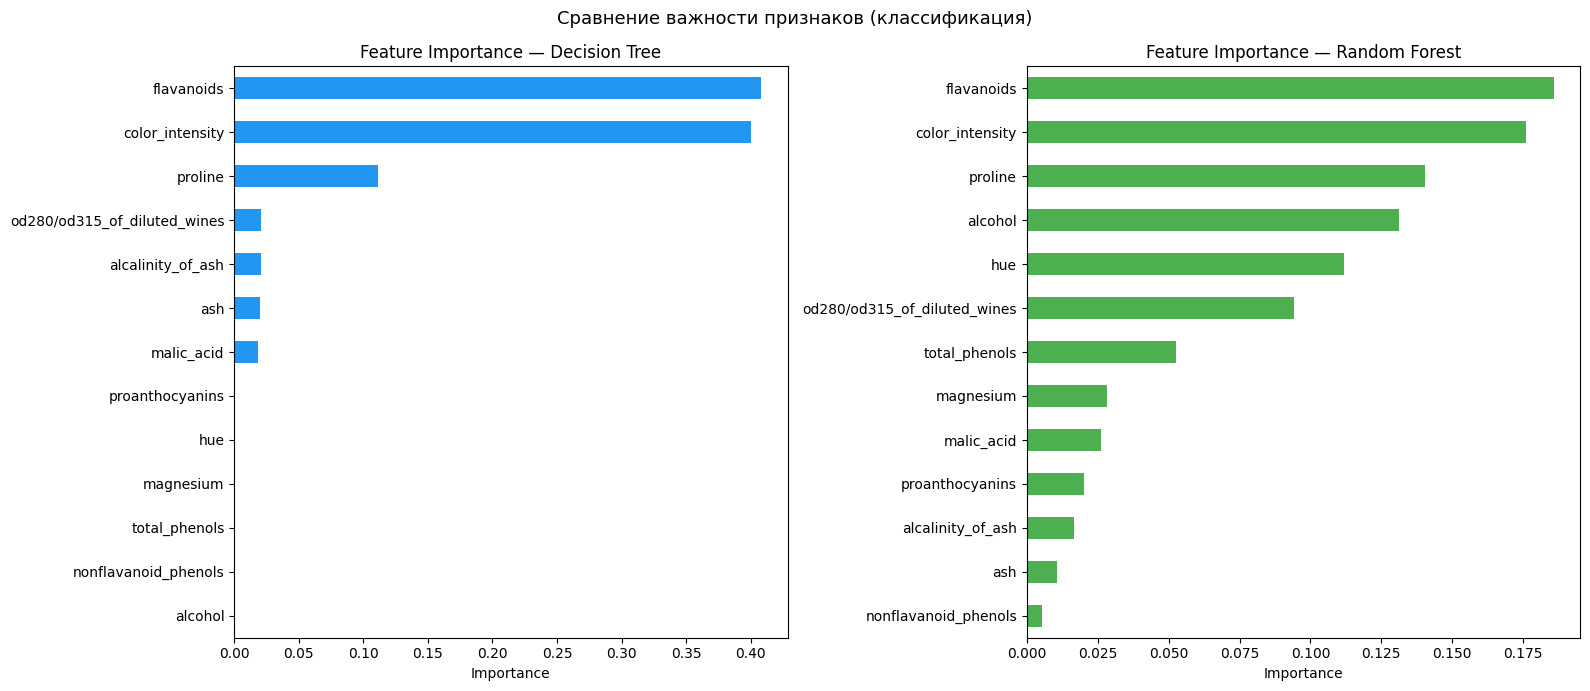

Самый значимый признак (Decision Tree): flavanoids (0.4081)
Самый значимый признак (Random Forest): flavanoids (0.1857)


In [23]:
# Feature importance для обеих моделей
fi_dt = pd.Series(dt_final.feature_importances_, index=wine.feature_names).sort_values(ascending=True)
fi_rf = pd.Series(rf_final.feature_importances_, index=wine.feature_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

fi_dt.plot(kind='barh', ax=axes[0], color='#2196F3')
axes[0].set_title('Feature Importance — Decision Tree')
axes[0].set_xlabel('Importance')

fi_rf.plot(kind='barh', ax=axes[1], color='#4CAF50')
axes[1].set_title('Feature Importance — Random Forest')
axes[1].set_xlabel('Importance')

plt.suptitle('Сравнение важности признаков (классификация)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Самый значимый признак (Decision Tree): {fi_dt.idxmax()} ({fi_dt.max():.4f})')
print(f'Самый значимый признак (Random Forest): {fi_rf.idxmax()} ({fi_rf.max():.4f})')

## Итоги — Классификация

- **Decision Tree** — интерпретируемая модель, но склонна к переобучению. Pruning (ограничение глубины) значительно улучшает обобщение.
- **Random Forest** — ансамбль деревьев, даёт более стабильные и точные результаты за счёт bagging.
- **Precision важнее Recall** в контексте виноделия: неправильная классификация сорта вина ведёт к репутационным потерям.
- Наиболее значимые признаки для классификации вина: flavanoids, proline, color_intensity.